# Qwen-Image 2.1 image generation with OpenVINO

Qwen-Image 2.1 is a unified image generation model that supports text-to-image generation and image-conditioned editing in one pipeline. The prompt and condition images are encoded together by Qwen3-VL and processed by a block-causal diffusion transformer.

For model architecture and usage details, see the [`Qwen/Qwen-Image-2.1`](https://huggingface.co/Qwen/Qwen-Image-2.1) model card and the [Qwen-Image source repository](https://github.com/QwenLM/Qwen-Image).

This tutorial demonstrates how to:

- download and convert [Qwen-Image 2.1](https://huggingface.co/Qwen/Qwen-Image-2.1) to OpenVINO IR;
- run text-to-image generation with OpenVINO GenAI;
- run image-conditioned editing with the same exported model;
- measure pipeline loading, first-run, and warm-run latency;
- launch an interactive demo.

> **Important:** Qwen-Image 2.1 image conditioning is not classic image-to-image generation based on adding noise to an initial image. The condition image is part of the multimodal context, so this notebook intentionally does not expose a `strength` parameter.

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

> **Resource note:** Conversion and inference may require substantial RAM and disk space. Start with FP16 and a 1024 x 1024 output; enable compression only after validating model quality.

#### Table of contents:

- [Prerequisites](#Prerequisites)
    - [Installation](#Installation)
- [Select model and export options](#Select-model-and-export-options)
- [Convert the model to OpenVINO IR](#Convert-the-model-to-OpenVINO-IR)
- [Run OpenVINO GenAI inference](#Run-OpenVINO-GenAI-inference)
    - [Text-to-image](#Text-to-image)
        - [Release the text-to-image pipeline](#Release-the-text-to-image-pipeline)
    - [Image-conditioned editing](#Image-conditioned-editing)
        - [Release the image editing pipeline](#Release-the-image-editing-pipeline)
- [Benchmark](#Benchmark)
- [Interactive demo](#Interactive-demo)

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/qwen-image-2.1/qwen-image-2.1.ipynb" />



## Prerequisites
[back to top ⬆️](#Table-of-contents:)

This notebook downloads [`Qwen/Qwen-Image-2.1`](https://huggingface.co/Qwen/Qwen-Image-2.1) from the Hugging Face Hub during conversion.

The installation uses:

1. the merged Qwen-Image 2.1 support from the Optimum Intel `main` branch;
2. OpenVINO, OpenVINO Tokenizers, and OpenVINO GenAI nightly wheels;
3. the Diffusers `main` branch containing Qwen-Image 2.1 support.


In [1]:
import os
import requests
from pathlib import Path

import ipywidgets as widgets
from IPython.display import display

for fname in ("notebook_utils.py", "cmd_helper.py", "pip_helper.py"):
    if not Path(fname).exists():
        response = requests.get(
            f"https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/{fname}",
            timeout=30,
        )
        response.raise_for_status()
        Path(fname).write_text(response.text, encoding="utf-8")

from pip_helper import pip_install

pip_install(
    "-qU",
    "gradio",
    "torch",
    "accelerate",
    "nncf",
    "numpy",
    "pillow",
    "ipywidgets",
    "tqdm",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("qwen-image-2.1.ipynb")

### Installation
[back to top ⬆️](#Table-of-contents:)

Install the required dependencies:

- Gradio, PyTorch, NNCF, and utility packages are upgraded to their latest stable versions.
- Optimum Intel and Diffusers are installed from their upstream `main` branches.
- OpenVINO, OpenVINO Tokenizers, and OpenVINO GenAI are installed from the OpenVINO nightly wheel index.
- Until post-merge GenAI nightlies are available, the cell uses matching Windows or Linux wheels from the merged runtime commit artifacts on the main branch. It first reuses wheels unpacked under `artifacts/wheels`, then optionally tries `GITHUB_TOKEN`, `GH_TOKEN`, or `gh auth token`. If automatic access is unavailable, it prints the exact workflow run, artifact names, and local destination for manual browser download without a token.

Restart the notebook kernel after installing or changing these packages.


In [2]:
pip_install(
    "-qU",
    "git+https://github.com/huggingface/diffusers.git@main",
    "git+https://github.com/huggingface/optimum-intel.git@main",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install(
    "-qU",
    "--pre",
    "openvino!=2026.5.0.0b1",
    "--extra-index-url",
    "https://storage.openvinotoolkit.org/simple/wheels/nightly",
)

import io
import platform
import shutil
import subprocess
import sys
import zipfile
from pathlib import Path

try:
    pip_install(
        "-qU",
        "--pre",
        "openvino-tokenizers>=2026.5.0.0.dev20260919,!=2026.5.0.0b1",
        "openvino-genai>=2026.5.0.0.dev20260919,!=2026.5.0.0b1",
        "--extra-index-url",
        "https://storage.openvinotoolkit.org/simple/wheels/nightly",
    )
except subprocess.CalledProcessError:
    print("Post-merge nightly wheels are unavailable; using wheels from the merged runtime commit artifacts.")

    artifact_builds = {
        "Windows": {
            "run_id": 35437002685,
            "genai_wheel_python_3.10": 10582936010,
            "genai_wheel_python_3.11": 10583275680,
            "genai_wheel_python_3.12": 10582492399,
            "genai_wheel_python_3.13": 10582697021,
            "genai_wheels": 10582901656,
        },
        "Linux": {
            "run_id": 35437002736,
            "genai_wheel_python_3.10": 10582437315,
            "genai_wheel_python_3.11": 10582322767,
            "genai_wheel_python_3.12": 10582781861,
            "genai_wheel_python_3.13": 10582622176,
            "genai_wheels": 10582871725,
        },
    }
    system = platform.system()
    python_version = f"{sys.version_info.major}.{sys.version_info.minor}"
    genai_artifact_name = f"genai_wheel_python_{python_version}"
    if platform.machine().lower() not in {"amd64", "x86_64"} or system not in artifact_builds or genai_artifact_name not in artifact_builds[system]:
        raise RuntimeError(f"No Qwen-Image 2.1 CI wheels are available for {system} " f"{platform.machine()} and Python {python_version}.")

    build = artifact_builds[system]
    artifact_names = (genai_artifact_name, "genai_wheels")
    wheels_dir = Path("artifacts") / "wheels" / system.lower()
    python_tag = f"cp{sys.version_info.major}{sys.version_info.minor}"

    def unpack_local_artifacts() -> None:
        for artifact_name in artifact_names:
            for archive_path in wheels_dir.glob(f"{artifact_name}*.zip"):
                print(f"Extracting {archive_path.name}...")
                with zipfile.ZipFile(archive_path) as archive:
                    wheel_members = [member for member in archive.namelist() if member.endswith(".whl")]
                    if not wheel_members:
                        raise RuntimeError(f"Downloaded artifact {archive_path} contains no Python wheels.")
                    for member in wheel_members:
                        wheel_path = wheels_dir / Path(member).name
                        wheel_path.write_bytes(archive.read(member))

    def find_required_wheels() -> list[Path]:
        wheels = list(wheels_dir.rglob("*.whl")) if wheels_dir.exists() else []
        genai_wheels = [wheel for wheel in wheels if wheel.name.startswith("openvino_genai-") and python_tag in wheel.name]
        tokenizer_wheels = [wheel for wheel in wheels if wheel.name.startswith("openvino_tokenizers-")]
        if len(genai_wheels) == 1 and len(tokenizer_wheels) == 1:
            return [genai_wheels[0], tokenizer_wheels[0]]
        return []

    def resolve_github_token() -> str | None:
        token = os.getenv("GITHUB_TOKEN") or os.getenv("GH_TOKEN")
        if not token and shutil.which("gh"):
            result = subprocess.run(["gh", "auth", "token"], capture_output=True, text=True, check=False)
            if result.returncode == 0:
                token = result.stdout.strip()
        return token

    def download_artifacts(token: str) -> None:
        headers = {
            "Accept": "application/vnd.github+json",
            "Authorization": f"Bearer {token}",
            "X-GitHub-Api-Version": "2022-11-28",
        }
        wheels_dir.mkdir(parents=True, exist_ok=True)
        for artifact_name in artifact_names:
            artifact_id = build[artifact_name]
            response = requests.get(
                f"https://api.github.com/repos/openvinotoolkit/openvino.genai/actions/artifacts/{artifact_id}/zip",
                headers=headers,
                timeout=600,
            )
            response.raise_for_status()
            with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
                for member in archive.namelist():
                    if member.endswith(".whl"):
                        wheel_path = wheels_dir / Path(member).name
                        wheel_path.write_bytes(archive.read(member))

    unpack_local_artifacts()
    required_wheels = find_required_wheels()
    if not required_wheels:
        github_token = resolve_github_token()
        if github_token:
            try:
                download_artifacts(github_token)
            except requests.HTTPError as error:
                if error.response.status_code not in {401, 403}:
                    raise
                print("Automatic GitHub artifact download was rejected: " f"{error.response.status_code} {error.response.text}")
        required_wheels = find_required_wheels()

    if not required_wheels:
        run_url = "https://github.com/openvinotoolkit/openvino.genai/actions/runs/" f"{build['run_id']}"
        genai_artifact_url = f"{run_url}/artifacts/{build[genai_artifact_name]}"
        common_artifact_url = f"{run_url}/artifacts/{build['genai_wheels']}"
        raise FileNotFoundError(
            "Open these links in a browser while signed in to GitHub:\n"
            f"  {genai_artifact_name}: {genai_artifact_url}\n"
            f"  genai_wheels: {common_artifact_url}\n"
            "If a direct link does not open, use the workflow run page:\n"
            f"  {run_url}\n"
            "Download both ZIP files into:\n"
            f"  {wheels_dir.resolve()}\n"
            "Then rerun this cell; it will unpack and install the wheels automatically. "
            "A GitHub token is not needed for this manual path."
        ) from None

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-qU",
            "--force-reinstall",
            "--no-deps",
            *map(str, required_wheels),
        ]
    )

print("Packages installed. Restart the notebook kernel before continuing.")

Packages installed. Restart the notebook kernel before continuing.


## Select model and export options
[back to top ⬆️](#Table-of-contents:)

The source model is [`Qwen/Qwen-Image-2.1`](https://huggingface.co/Qwen/Qwen-Image-2.1). The conversion downloads model files through the Hugging Face Hub cache and writes the OpenVINO model to a separate output directory.

`FP16` is the default until compressed-model quality has been evaluated. Selecting `INT8` or `INT4` enables Optimum Intel weight compression during export.


In [3]:
model_id = "Qwen/Qwen-Image-2.1"

export_root = widgets.Text(
    value=os.getenv("QWEN_IMAGE_21_OV_DIR", "qwen-image-2.1-ov"),
    description="Export folder:",
    layout=widgets.Layout(width="90%"),
    style={"description_width": "120px"},
)
weight_format = widgets.Dropdown(
    options=("FP16", "INT8", "INT4"),
    value="FP16",
    description="Weights:",
    style={"description_width": "120px"},
)

print(f"Source model: https://huggingface.co/{model_id}")
display(export_root, weight_format)

Source model: https://huggingface.co/Qwen/Qwen-Image-2.1


Text(value='qwen-image-2.1-ov', description='Export folder:', layout=Layout(width='90%'), style=TextStyle(desc…

Dropdown(description='Weights:', options=('FP16', 'INT8', 'INT4'), style=DescriptionStyle(description_width='1…

In [ ]:
export_base_dir = Path(export_root.value).expanduser()
model_dir = export_base_dir / weight_format.value

additional_args = {
    "task": "text-to-image",
    "weight-format": weight_format.value.lower(),
}
if weight_format.value == "INT4":
    additional_args.update({"group-size-fallback": "ignore"})

print(f"Hugging Face source model: {model_id}")
print(f"OpenVINO output: {model_dir.resolve()}")

## Convert the model to OpenVINO IR
[back to top ⬆️](#Table-of-contents:)

Optimum CLI downloads the source model from the Hugging Face Hub and exports it to the selected local directory. The conversion is skipped only when the completion marker matches the selected model and weight format.

Delete or rename the target directory to force a clean reconversion after updating Optimum Intel or the nightly OpenVINO packages.


In [ ]:
from cmd_helper import optimum_cli

export_complete_marker = model_dir / ".openvino_export_complete"
export_signature = f"model_id={model_id}\nweight_format={weight_format.value}\n"

if export_complete_marker.is_file():
    if export_complete_marker.read_text(encoding="utf-8") != export_signature:
        raise RuntimeError(
            f"The export in {model_dir.resolve()} was created from another source or configuration. "
            "Remove it or select another export folder before retrying."
        )
    print(f"Using existing OpenVINO model from {model_dir.resolve()}")
elif model_dir.exists():
    raise RuntimeError(
        f"The export directory {model_dir.resolve()} exists but has no completion marker. "
        "It is probably left from an interrupted export. Remove it or select another export folder before retrying."
    )
else:
    optimum_cli(model_id, model_dir, additional_args=additional_args)
    export_complete_marker.write_text(export_signature, encoding="utf-8")

## Run OpenVINO GenAI inference
[back to top ⬆️](#Table-of-contents:)

The exported directory is used by both OpenVINO GenAI pipelines. Qwen-Image 2.1 defaults are used throughout the notebook:

- 40 denoising steps;
- guidance scale 1.0;
- no negative prompt;
- 1024 x 1024 output;
- fixed random seed.

The pipeline-specific construction and generation calls are kept in isolated cells so the T2I and image-editing lifecycles remain explicit.


In [6]:
import gc
import time
from datetime import datetime
from typing import Any

import numpy as np
import openvino as ov
import openvino_genai as ov_genai
from PIL import Image, ImageOps
from tqdm.auto import tqdm

from notebook_utils import device_widget


def image_to_tensor(image: Image.Image) -> ov.Tensor:
    """Convert a PIL image to an NHWC OpenVINO tensor."""
    image_data = np.asarray(image.convert("RGB"), dtype=np.uint8)[None]
    return ov.Tensor(image_data)


def output_to_image(output: Any) -> Image.Image:
    """Convert an OpenVINO GenAI image output to a PIL image."""
    data = output.data if hasattr(output, "data") else output
    array = np.asarray(data)
    if array.ndim == 4:
        array = array[0]
    return Image.fromarray(array).convert("RGB")


def make_image_comparison(source_image: Image.Image, generated_image: Image.Image) -> Image.Image:
    """Place source and generated images side by side."""
    source_preview = ImageOps.fit(source_image, generated_image.size, method=Image.Resampling.LANCZOS)
    comparison = Image.new("RGB", (generated_image.width * 2, generated_image.height))
    comparison.paste(source_preview, (0, 0))
    comparison.paste(generated_image, (generated_image.width, 0))
    return comparison


def save_generated_image(image: Image.Image, scenario: str, precision: str, inference_device: str, seed: int) -> Path:
    """Save a generated image with its inference configuration in the filename."""
    output_dir = Path("generated_images")
    output_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S-%f")
    safe_device = inference_device.replace(":", "-").replace(".", "-")
    output_path = output_dir / f"qwen-image-2.1-{scenario}-{precision.lower()}-{safe_device.lower()}-seed{seed}-{timestamp}.png"
    image.save(output_path)
    print(f"Saved image to {output_path.resolve()}")
    return output_path


def generate_with_progress(
    pipeline: Any,
    *args: Any,
    num_inference_steps: int,
    description: str,
    **kwargs: Any,
) -> Any:
    """Run image generation while displaying denoising progress."""
    progress = tqdm(total=num_inference_steps, desc=description)

    def callback(step: int, num_steps: int, latent: Any) -> bool:
        completed_steps = min(step + 1, num_steps)
        progress.update(max(0, completed_steps - progress.n))
        return False

    try:
        return pipeline.generate(
            *args,
            num_inference_steps=num_inference_steps,
            callback=callback,
            **kwargs,
        )
    finally:
        progress.close()


def print_perf_metrics(output: Any) -> None:
    """Print available OpenVINO GenAI image performance metrics."""
    metrics = getattr(output, "perf_metrics", None)
    if metrics is None:
        print("This OpenVINO GenAI image output does not expose perf_metrics; wall-clock metrics are used.")
        return

    metric_methods = {
        "Load time": "get_load_time",
        "Generate duration": "get_generate_duration",
        "Transformer duration": "get_transformer_infer_duration",
        "VAE encoder duration": "get_vae_encoder_infer_duration",
        "VAE decoder duration": "get_vae_decoder_infer_duration",
    }
    for label, method_name in metric_methods.items():
        method = getattr(metrics, method_name, None)
        if method is not None:
            print(f"{label}: {method()}")


device = device_widget(default="CPU", exclude=["NPU"])
device

Dropdown(description='Device:', options=('CPU', 'GPU.0', 'GPU.1', 'AUTO'), value='CPU')

### Text-to-image
[back to top ⬆️](#Table-of-contents:)

Load the text-to-image pipeline and record model loading time separately from generation latency.


In [7]:
t2i_load_started = time.perf_counter()
t2i_pipe = ov_genai.Text2ImagePipeline(str(model_dir), device.value)
t2i_load_seconds = time.perf_counter() - t2i_load_started

print(f"Text-to-image pipeline load time: {t2i_load_seconds:.2f} s")

Text-to-image pipeline load time: 12.59 s


Text-to-image:   0%|          | 0/40 [00:00<?, ?it/s]

First text-to-image generation: 34.41 s
This OpenVINO GenAI image output does not expose perf_metrics; wall-clock metrics are used.
Saved image to C:\Users\sys_ovwindev\qwen-image-2-1\openvino_notebooks\notebooks\qwen-image-2.1\generated_images\qwen-image-2.1-t2i-int4-gpu-1-seed21-20260920-181223-204320.png


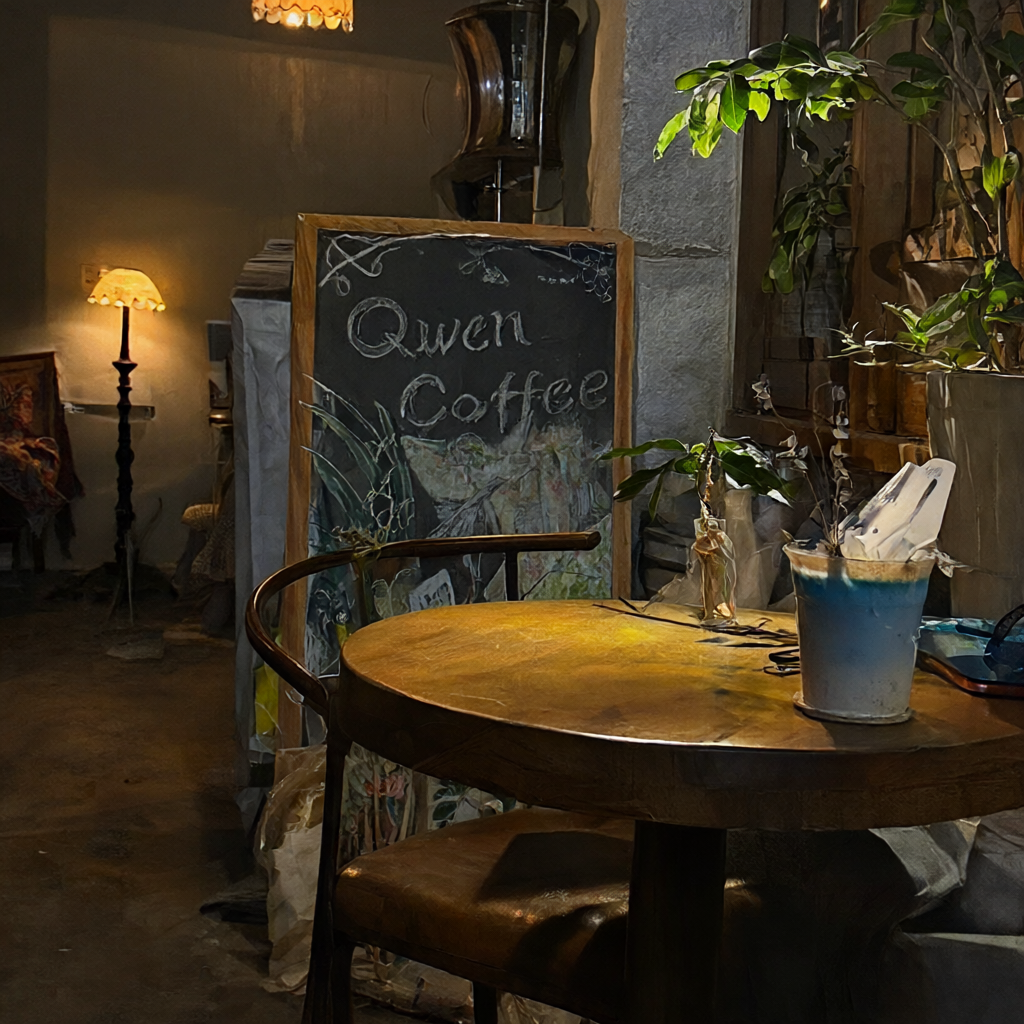

In [8]:
t2i_prompt = 'A cozy coffee shop with a chalkboard sign reading "Qwen Coffee", cinematic lighting'
t2i_num_inference_steps = 40
t2i_seed = 21

t2i_first_started = time.perf_counter()
t2i_output = generate_with_progress(
    t2i_pipe,
    t2i_prompt,
    height=1024,
    width=1024,
    guidance_scale=1.0,
    num_inference_steps=t2i_num_inference_steps,
    description="Text-to-image",
    generator=ov_genai.TorchGenerator(t2i_seed),
)
t2i_first_run_seconds = time.perf_counter() - t2i_first_started

print(f"First text-to-image generation: {t2i_first_run_seconds:.2f} s")
print_perf_metrics(t2i_output)
t2i_image = output_to_image(t2i_output)
t2i_output_path = save_generated_image(t2i_image, "t2i", weight_format.value, device.value, t2i_seed)
t2i_image

#### Release the text-to-image pipeline
[back to top ⬆️](#Table-of-contents:)

Release the compiled text-to-image pipeline before loading the image editing pipeline.


In [9]:
if "t2i_pipe" in globals():
    del t2i_pipe
    gc.collect()
    print("Text-to-image pipeline released.")
else:
    print("Text-to-image pipeline is not loaded.")

Text-to-image pipeline released.


### Image-conditioned editing
[back to top ⬆️](#Table-of-contents:)

Select a local condition image and describe the requested edit. The image is multimodal context for Qwen-Image 2.1; it is not a noisy initialization controlled by `strength`.

`Image2ImagePipeline` receives the condition tensor as the second positional argument. Height and width are intentionally omitted: the Qwen-Image 2.1 pipeline derives a 32-aligned output resolution near 1024² pixels from the condition image aspect ratio.


In [10]:
sample_image_url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
sample_image_path = Path("sample_cat.png")
if not sample_image_path.is_file():
    response = requests.get(sample_image_url, timeout=30)
    response.raise_for_status()
    sample_image_path.write_bytes(response.content)

input_image_path = widgets.Text(
    value=os.getenv("QWEN_IMAGE_21_INPUT_IMAGE", str(sample_image_path)),
    description="Input image:",
    placeholder="Path to a local image used for editing",
    layout=widgets.Layout(width="90%"),
    style={"description_width": "120px"},
)
input_image_path

Text(value='sample_cat.png', description='Input image:', layout=Layout(width='90%'), placeholder='Path to a lo…

Image editing:   0%|          | 0/40 [00:00<?, ?it/s]

Image editing pipeline load time: 14.20 s
First image editing generation: 107.67 s
This OpenVINO GenAI image output does not expose perf_metrics; wall-clock metrics are used.
Saved image to C:\Users\sys_ovwindev\qwen-image-2-1\openvino_notebooks\notebooks\qwen-image-2.1\generated_images\qwen-image-2.1-editing-int4-gpu-1-seed42-20260920-181425-435876.png


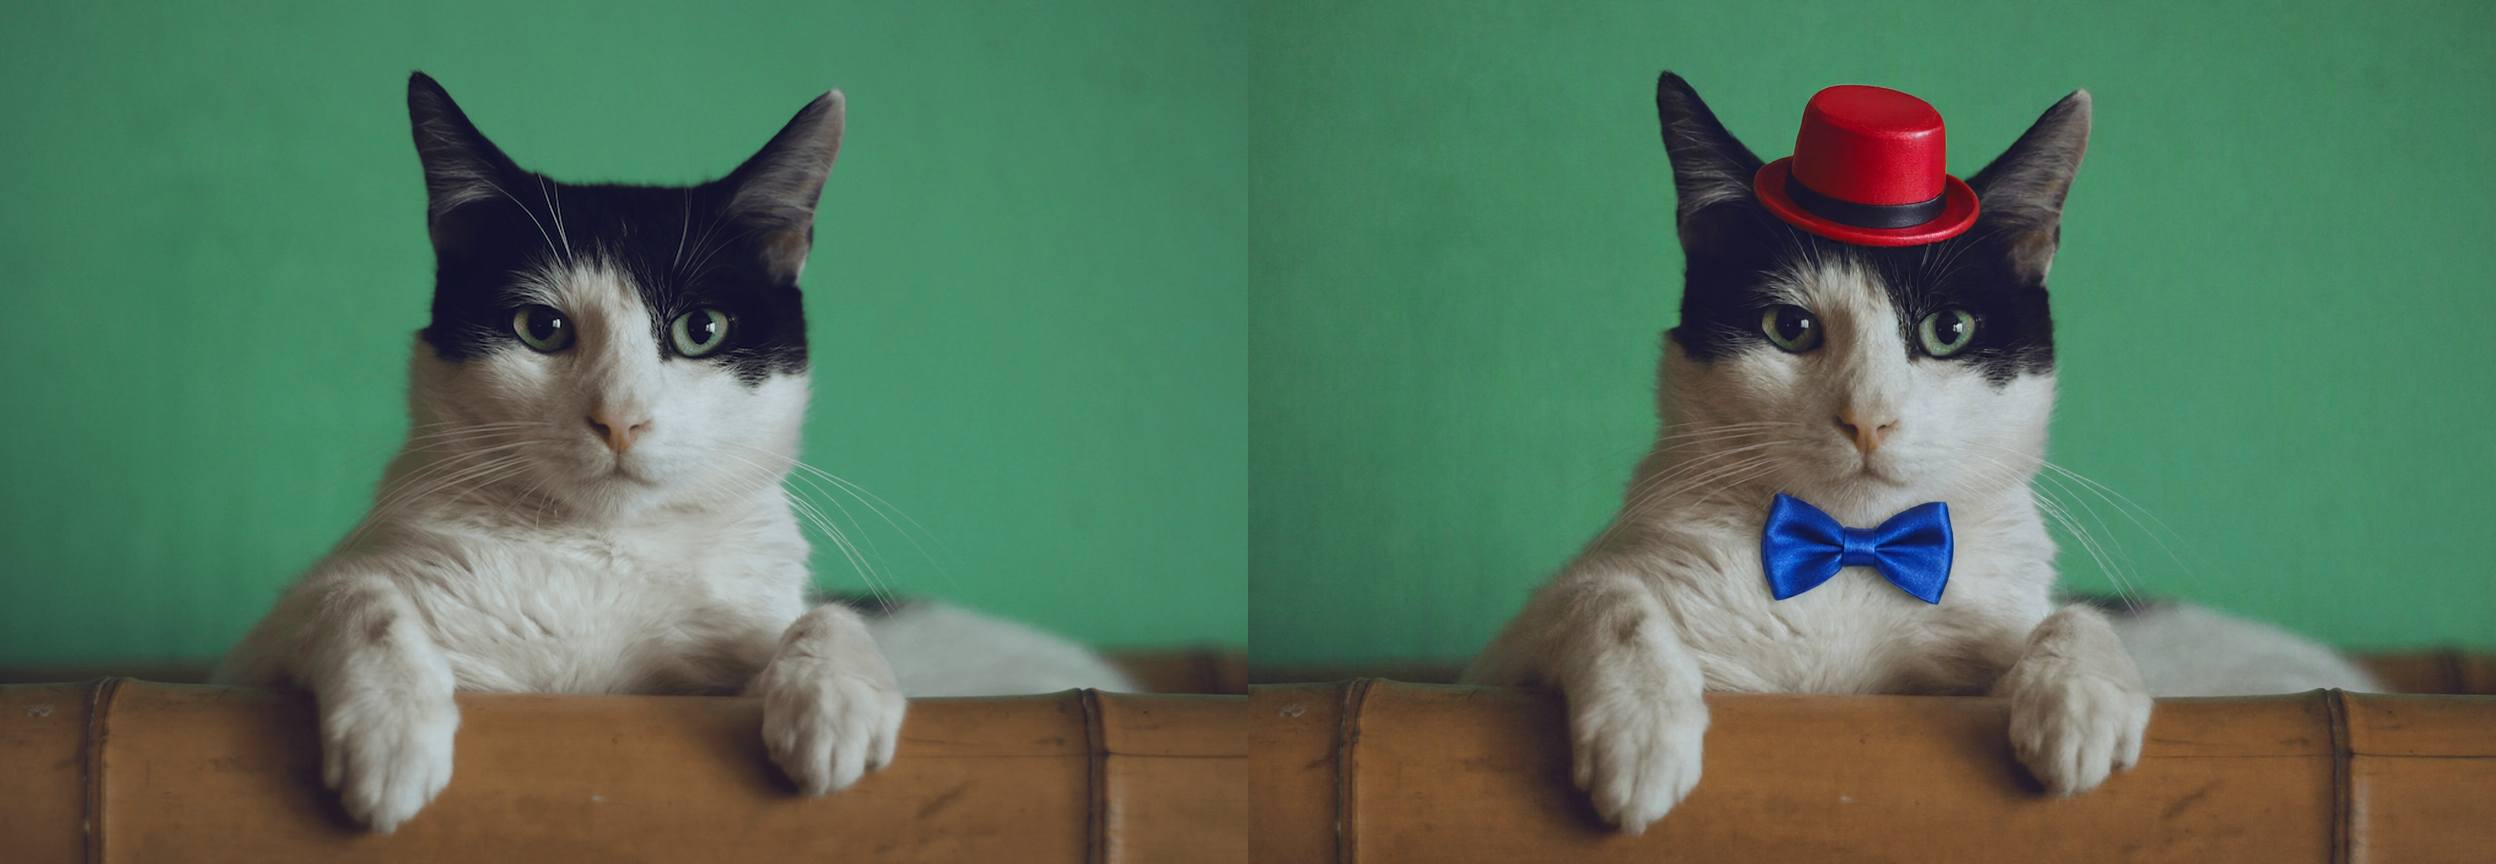

In [11]:
condition_image_path = Path(input_image_path.value).expanduser()
if not condition_image_path.is_file():
    raise FileNotFoundError("Set QWEN_IMAGE_21_INPUT_IMAGE or the Input image widget to a local image file.")

condition_image = Image.open(condition_image_path).convert("RGB")
condition_tensor = image_to_tensor(condition_image)
edit_prompt = "Put a tiny red top hat and a blue bow tie on the cat. Preserve the cat's identity, face, pose, and the original composition."
i2i_num_inference_steps = 40
i2i_seed = 42

i2i_load_started = time.perf_counter()
i2i_pipe = ov_genai.Image2ImagePipeline(str(model_dir), device.value)
i2i_load_seconds = time.perf_counter() - i2i_load_started

i2i_first_started = time.perf_counter()
i2i_output = generate_with_progress(
    i2i_pipe,
    edit_prompt,
    condition_tensor,
    guidance_scale=1.0,
    num_inference_steps=i2i_num_inference_steps,
    description="Image editing",
    generator=ov_genai.TorchGenerator(i2i_seed),
)
i2i_first_run_seconds = time.perf_counter() - i2i_first_started

print(f"Image editing pipeline load time: {i2i_load_seconds:.2f} s")
print(f"First image editing generation: {i2i_first_run_seconds:.2f} s")
print_perf_metrics(i2i_output)
i2i_image = output_to_image(i2i_output)
i2i_output_path = save_generated_image(i2i_image, "editing", weight_format.value, device.value, i2i_seed)
i2i_comparison = make_image_comparison(condition_image, i2i_image)
i2i_comparison

#### Release the image editing pipeline
[back to top ⬆️](#Table-of-contents:)

Release the compiled image editing pipeline before running benchmarks or launching the interactive demo.


In [12]:
if "i2i_pipe" in globals():
    del i2i_pipe
    gc.collect()
    print("Image editing pipeline released.")
else:
    print("Image editing pipeline is not loaded.")

Image editing pipeline released.


## Benchmark
[back to top ⬆️](#Table-of-contents:)

The benchmark reports end-to-end pipeline latency rather than isolated OpenVINO IR component performance.

- Pipeline loading and the first generation are measured in this benchmark cell.
- The first generation serves as the excluded warm-up run.
- Warm latency reports minimum, median, mean, standard deviation, and individual measurements.
- T2I and image-conditioned editing are loaded, measured, and released sequentially.
- The report includes the actual output resolution, device, precision, inference settings, and cold total (`load + first generation`).

For reproducible comparisons, keep the device, precision, resolution, number of steps, guidance scale, prompt, condition image, and KV-cache behavior unchanged. Close other resource-intensive applications before collecting final numbers.

Run the next cell, select the number of measured warm runs, and then run the benchmark cell below it. Five runs are used by default to make occasional slow runs visible without making this expensive benchmark excessively long.


In [13]:
benchmark_runs = widgets.IntSlider(
    value=5,
    min=3,
    max=10,
    step=1,
    description="Warm runs:",
    style={"description_width": "100px"},
)
benchmark_runs

IntSlider(value=5, description='Warm runs:', max=10, min=3, style=SliderStyle(description_width='100px'))

In [14]:
from statistics import mean, median, pstdev
from typing import Callable


def benchmark_generation(generate: Callable[[], Any], runs: int) -> tuple[dict[str, Any], Any]:
    """Measure repeated generation latency and return the last output."""
    durations = []
    output = None
    for _ in range(runs):
        started = time.perf_counter()
        output = generate()
        durations.append(time.perf_counter() - started)

    return {
        "minimum": min(durations),
        "median": median(durations),
        "mean": mean(durations),
        "stddev": pstdev(durations),
        "durations": durations,
    }, output


BENCHMARK_STEPS = 40
BENCHMARK_GUIDANCE_SCALE = 1.0


def generate_t2i_benchmark(pipeline: Any) -> Any:
    """Generate the text-to-image benchmark sample."""
    return pipeline.generate(
        t2i_prompt,
        height=1024,
        width=1024,
        guidance_scale=BENCHMARK_GUIDANCE_SCALE,
        num_inference_steps=BENCHMARK_STEPS,
        generator=ov_genai.TorchGenerator(t2i_seed),
    )


def generate_i2i_benchmark(pipeline: Any) -> Any:
    """Generate the image-editing benchmark sample."""
    return pipeline.generate(
        edit_prompt,
        condition_tensor,
        guidance_scale=BENCHMARK_GUIDANCE_SCALE,
        num_inference_steps=BENCHMARK_STEPS,
        generator=ov_genai.TorchGenerator(i2i_seed),
    )


t2i_load_started = time.perf_counter()
t2i_benchmark_pipe = ov_genai.Text2ImagePipeline(str(model_dir), device.value)
t2i_benchmark_load_seconds = time.perf_counter() - t2i_load_started
try:
    t2i_first_started = time.perf_counter()
    t2i_first_output = generate_t2i_benchmark(t2i_benchmark_pipe)
    t2i_benchmark_first_seconds = time.perf_counter() - t2i_first_started
    del t2i_first_output

    t2i_warm, t2i_benchmark_output = benchmark_generation(
        lambda: generate_t2i_benchmark(t2i_benchmark_pipe),
        benchmark_runs.value,
    )
    t2i_benchmark_size = output_to_image(t2i_benchmark_output).size
    del t2i_benchmark_output
finally:
    del t2i_benchmark_pipe
    gc.collect()

i2i_load_started = time.perf_counter()
i2i_benchmark_pipe = ov_genai.Image2ImagePipeline(str(model_dir), device.value)
i2i_benchmark_load_seconds = time.perf_counter() - i2i_load_started
try:
    i2i_first_started = time.perf_counter()
    i2i_first_output = generate_i2i_benchmark(i2i_benchmark_pipe)
    i2i_benchmark_first_seconds = time.perf_counter() - i2i_first_started
    del i2i_first_output

    i2i_warm, i2i_benchmark_output = benchmark_generation(
        lambda: generate_i2i_benchmark(i2i_benchmark_pipe),
        benchmark_runs.value,
    )
    i2i_benchmark_size = output_to_image(i2i_benchmark_output).size
    del i2i_benchmark_output
finally:
    del i2i_benchmark_pipe
    gc.collect()

benchmark_results = {
    "Text-to-image": {
        "resolution": t2i_benchmark_size,
        "load": t2i_benchmark_load_seconds,
        "first": t2i_benchmark_first_seconds,
        **t2i_warm,
    },
    "Image editing": {
        "resolution": i2i_benchmark_size,
        "load": i2i_benchmark_load_seconds,
        "first": i2i_benchmark_first_seconds,
        **i2i_warm,
    },
}

print("Benchmark configuration:")
print(f"  Device: {device.value}")
print(f"  Precision: {weight_format.value}")
print(f"  Inference steps: {BENCHMARK_STEPS}")
print(f"  Guidance scale: {BENCHMARK_GUIDANCE_SCALE}")
print("  Warm-up runs: 1 (first generation)")
print(f"  Measured warm runs: {benchmark_runs.value}")
print(f"  Editing condition: {condition_image.width}x{condition_image.height}\n")

print(
    f"{'Scenario':<18} {'Resolution':>12} {'Load (s)':>9} {'First (s)':>10} "
    f"{'Cold total (s)':>14} {'Min (s)':>9} {'Median (s)':>11} "
    f"{'Mean (s)':>10} {'Std (s)':>9}"
)
for scenario, values in benchmark_results.items():
    resolution = f"{values['resolution'][0]}x{values['resolution'][1]}"
    cold_total = values["load"] + values["first"]
    print(
        f"{scenario:<18} {resolution:>12} {values['load']:>9.2f} "
        f"{values['first']:>10.2f} {cold_total:>14.2f} "
        f"{values['minimum']:>9.2f} {values['median']:>11.2f} "
        f"{values['mean']:>10.2f} {values['stddev']:>9.2f}"
    )

print("\nIndividual warm runs:")
for scenario, values in benchmark_results.items():
    samples = ", ".join(f"{duration:.2f}" for duration in values["durations"])
    print(f"  {scenario}: {samples} s")

editing_to_t2i_ratio = benchmark_results["Image editing"]["median"] / benchmark_results["Text-to-image"]["median"]
print(f"\nImage editing / T2I warm median ratio: {editing_to_t2i_ratio:.2f}x")

Benchmark configuration:
  Device: GPU.1
  Precision: INT4
  Inference steps: 40
  Guidance scale: 1.0
  Warm-up runs: 1 (first generation)
  Measured warm runs: 5
  Editing condition: 1024x704

Scenario             Resolution  Load (s)  First (s) Cold total (s)   Min (s)  Median (s)   Mean (s)   Std (s)
Text-to-image         1024x1024     11.49      30.99          42.48     31.01       31.08      31.07      0.03
Image editing          1248x864     14.04     105.89         119.93    102.24      102.33     102.70      0.75

Individual warm runs:
  Text-to-image: 31.01, 31.05, 31.08, 31.09, 31.11 s
  Image editing: 102.24, 104.20, 102.33, 102.33, 102.39 s

Image editing / T2I warm median ratio: 3.29x


## Interactive demo
[back to top ⬆️](#Table-of-contents:)

The demo allows selecting Text-to-Image or Image Editing, FP16/INT8/INT4 precision, and an available OpenVINO device. It keeps only the selected pipeline in memory and releases it when the configuration changes.


In [ ]:
from gradio_helper import make_demo

for pipeline_name in ("t2i_pipe", "i2i_pipe"):
    if pipeline_name in globals():
        del globals()[pipeline_name]
gc.collect()

demo = make_demo(
    model_root=export_base_dir,
    default_precision=weight_format.value,
    default_device=device.value,
    editing_sample=sample_image_path,
)

# if you are launching remotely, specify server_name and server_port
# demo.launch(server_name='your server name', server_port='server port in int')
# Read more in the docs: https://gradio.app/docs/
demo.launch(debug=True)